In [7]:
import math
import numpy as np
from datetime import timedelta
from operator import attrgetter
import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
from IPython.display import HTML
import zarr
from matplotlib.animation import FuncAnimation
import parcels
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from parcels import FieldSet
#!pip install h5py
Hocbuk-sibju3-wyzmac

#HOW TO API GLORYS DATA


import copernicusmarine

copernicusmarine.subset(
  dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
  variables=["uo", "vo"],
  minimum_longitude=-145.5,
  maximum_longitude=-136.5,
  minimum_latitude=0,
  maximum_latitude=12,
  start_datetime="2024-11-09T00:00:00",
  end_datetime="2025-05-24T00:00:00",
  minimum_depth=0.49402499198913574,
  maximum_depth=1062.43994140625,
)

In [8]:
# Uploading the motive dataset 
motive = xr.open_dataset('sg195_tropics_timeseries_cleaned.nc')
lat_motive = motive['latitude'].values
lon_motive = motive['longitude'].values

#motive_currents.coords['longitude'].isel(time=0)
#motive_currents['latitude'][0].values
#motive['latitude'][0].values

In [9]:
#Defining the kernel of Seaglider movements 

def SeagliderSpatialmovement(particle, fieldset, time):
    mindepth = 2 #m
    maxdepth = 1000 #m
    vertical_velocity = 0.10  #Desired velocity (m/s)

    # Phase 0 = descending 
    if particle.cycle_phase == 0:
        particle.depth = particle.depth + vertical_velocity * particle.dt

        if particle.depth >= maxdepth:
            particle.depth = maxdepth 
            particle.cycle_phase = 1 # Now it's ascending 
    # Phase 1 = ascending 
    elif particle.cycle_phase == 1:

        particle.depth = particle.depth - vertical_velocity * particle.dt

        if particle.depth <= mindepth:
            particle.depth = mindepth
            particle.cycle_phase = 0 # Back to descending 



In [11]:
filepath = "cmems_mod_glo_phy_my_0.083deg_P1D-m_uo-vo_145.50W-136.50W_0.00N-12.00N_0.49-1062.44m_2024-11-09-2025-05-24.nc"
motive_currents = xr.open_dataset(filepath)
filenames = {
    'U': {
        'lon': filepath,
        'lat': filepath,
        'depth': filepath,
        'data': filepath
    },
    'V': {
        'lon': filepath,
        'lat': filepath,
        'depth': filepath,
        'data': filepath
    }
}

variables = {
    'U': 'uo',
    'V': 'vo'
}

dimensions = {
    'U': {'lon': 'longitude', 'lat': 'latitude', 'depth': 'depth', 'time': 'time'},
    'V': {'lon': 'longitude', 'lat': 'latitude', 'depth': 'depth', 'time': 'time'}
}

fieldset = parcels.FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
    deferred_load=False
)

In [187]:
# Define a new Particle type including extra Variables
SeagliderParticle = parcels.JITParticle.add_variables(
    [
        # init_descend=0,
        # profile_descend=2,
        # profile_ascend=3,
        # transmit=4
        parcels.Variable("cycle_phase", dtype=np.int32, initial=0),
        parcels.Variable("age", initial=0.0)
        # if fieldset has temperature
        # Variable('temp', dtype=np.float32, initial=np.nan),
    ])



pset = parcels.ParticleSet(
    fieldset=fieldset,  # the fields that the particleset uses
    pclass=SeagliderParticle,  # define the type of particle
    lon=[-140.87872],  # release longitude
    lat=[5.2785225],  # release latitude
    depth=[2]
)

In [1]:
# combine seaglider vertical movement kernel with built-in Advection kernel
kernels = [SeagliderSpatialmovement, parcels.AdvectionRK4]

# Create a ParticleFile object to store the output
output_file = pset.ParticleFile(
    name="seaglider",
    outputdt=timedelta(minutes=1), # how often you store output in file 
    chunks=(1, 500),  # setting to write in chunks of 500 observations
)

# Now execute the kernel, setting your own dt
pset.execute(
    kernels,
    runtime=timedelta(days=2),
    dt=timedelta(seconds=30),
    output_file=output_file,
)

NameError: name 'SeagliderSpatialmovement' is not defined

Text(0.5, 0.92, 'Seaglider Path 10 Days dt= 5 min')

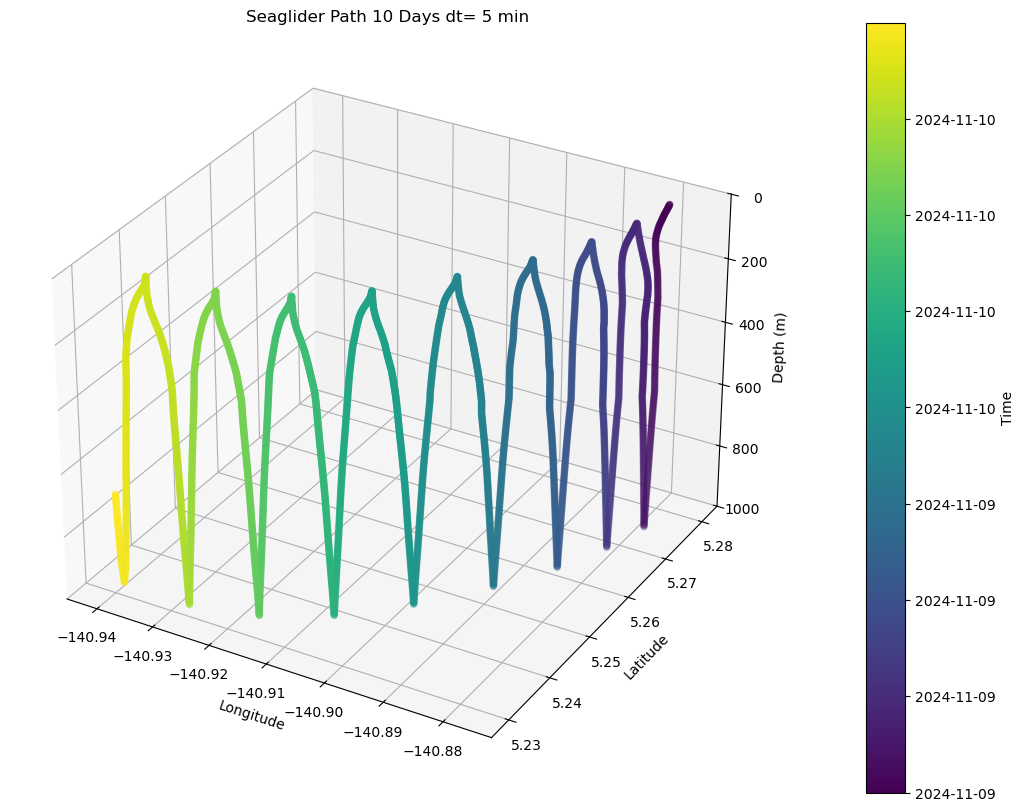

In [189]:
import matplotlib.dates as mdates
ds = xr.open_zarr("seaglider.zarr")
time_raw = ds["time"].values.squeeze() 
time = time_raw.astype("datetime64[ns]")
time_mpl = mdates.date2num(time.astype('datetime64[ms]').astype(object))

x = ds["lon"][:].squeeze()
y = ds["lat"][:].squeeze()
z = ds["z"][:].squeeze()
ds.close()

fig = plt.figure(figsize=(13, 10))
ax = plt.axes(projection="3d")

cb = ax.scatter(x, y, z, c=time_mpl, s=20, cmap="viridis")
cbar = plt.colorbar(cb, ax=ax, pad=0.1)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
cbar.set_label("Time")


ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth (m)")
ax.set_zlim(np.max(z), 0)
ax.set_title('Seaglider Path 10 Days dt= 5 min')
#plt.savefig('Seaglider_10_days_3D_5min_dt')


In [2]:
#My personal check to see where the model caps shoring

np.min(z).values


NameError: name 'np' is not defined

In [191]:

#ds.temperature.hvplot.quadmesh(x='time', y='depth', cmap='inferno')

In [192]:
mask = ds["z"] <= 5
lon_surface = ds["lon"].where(mask)
lat_surface = ds["lat"].where(mask)
time_surface = ds["time"].where(mask)
lon_surface = lon_surface.values.flatten()
lat_surface = lat_surface.values.flatten()
time_surface = time_surface.values.flatten()
valid = ~np.isnan(lon_surface)

lon_surface = lon_surface[valid]
lat_surface = lat_surface[valid]
time_surface = time_surface[valid]
lon_diff = np.diff(lon_surface)
lat_diff = np.diff(lat_surface)
time_diff = time_surface[1:]
df = pd.DataFrame({
    "time": time_diff,
    "lon_diff": lon_diff,
    "lat_diff": lat_diff
})

In [193]:
mask = ds["z"] <= 5
lon_surface = ds["lon"].where(mask)
lat_surface = ds["lat"].where(mask)
time_surface = ds["time"].where(mask)
lon_surface = lon_surface.values.flatten()
lat_surface = lat_surface.values.flatten()
time_surface = time_surface.values.flatten()
valid = ~np.isnan(lon_surface)

lon_surface = lon_surface[valid]
lat_surface = lat_surface[valid]
time_surface = time_surface[valid]
lon_diff = np.diff(lon_surface)
lat_diff = np.diff(lat_surface)
time_diff = time_surface[1:]
df = pd.DataFrame({
    "time": time_diff,
    "lon_diff": lon_diff,
    "lat_diff": lat_diff
})
df

,time,lon_diff,lat_diff
0,2024-11-09 05:32:00,-0.001312,-0.006441
1,2024-11-09 05:33:00,-0.000183,0.000177
2,2024-11-09 11:05:00,-0.002899,-0.007002
3,2024-11-09 11:06:00,-0.000183,0.000190
4,2024-11-09 16:38:00,-0.004639,-0.007578
5,2024-11-09 16:39:00,-0.000183,0.000203
6,2024-11-09 22:11:00,-0.006851,-0.008191
7,2024-11-09 22:12:00,-0.000183,0.000216
8,2024-11-10 03:44:00,-0.008347,-0.008131
9,2024-11-10 03:45:00,-0.000183,0.000219


In [194]:
start_lon = -139.16643   # replace with first lon value
start_lat = 0.73215336     # replace with first lat value
lon = np.cumsum(np.insert(df["lon_diff"].values, 0, 0)) + start_lon
lat = np.cumsum(np.insert(df["lat_diff"].values, 0, 0)) + start_lat
motive = motive.sortby('time')
times = pd.to_datetime(df['time'].values)

# get nearest indices
nearest = motive['time'].to_index().get_indexer(times, method='nearest')

filtered_motive = motive.isel(sg_data_point=nearest)
lat_motive = filtered_motive['latitude'].values
lon_motive = filtered_motive['longitude'].values
lon_motive

array([-139.16643, -139.16643, -139.16643, -139.16643, -139.16643,
       -139.16643, -139.16643, -139.16643, -139.16643, -139.16643,
       -139.16643, -139.16643, -139.16643, -139.16643, -139.16643,
       -139.16643], dtype=float32)

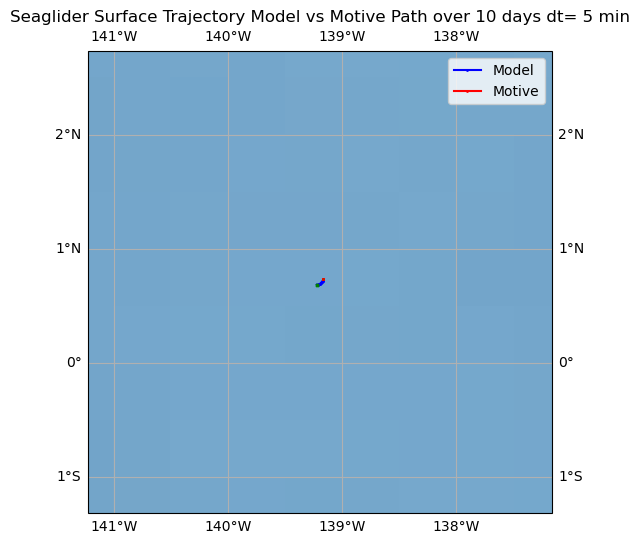

In [220]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.stock_img()
ax.plot(lon, lat, marker='o', markersize=1, color='b', transform=ccrs.PlateCarree(), zorder=1, label='Model')
ax.plot(lon_motive, lat_motive, marker='o', markersize=1, color='red', transform=ccrs.PlateCarree(), zorder=2, label='Motive')
ax.legend()
lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

# --- Motive start/end ---
#ax.plot(lon_motive[0], lat_motive[0], marker='o', color='yellow', markersize=.5,
  #      transform=ccrs.PlateCarree(), label='Motive Start', zorder=3)

#ax.plot(lon_motive[-1], lat_motive[-1], marker='X', color='yellow', markersize=.5,
       # transform=ccrs.PlateCarree(), label='Motive End', zorder=3)

# --- Model start/end ---
ax.plot(lon[0], lat[0], marker='o', color='green', markersize=.2,
        transform=ccrs.PlateCarree(), label='Model Start', zorder=3)

ax.plot(lon[-1], lat[-1], marker='X', color='green', markersize=2,
        transform=ccrs.PlateCarree(), label='Model End', zorder=3)

# Add a little padding (optional but recommended)
pad = 5  # degrees
ax.set_extent([lon_min - 2, lon_max + 2,
               lat_min - 2, lat_max + 2],
              crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Seaglider Surface Trajectory Model vs Motive Path over 10 days dt= 5 min")


ax.grid()
#plt.savefig("Modeled_path_10days_5mindt")

In [83]:
lat_motive = motive['latitude'].values
lon_motive = motive['longitude'].values

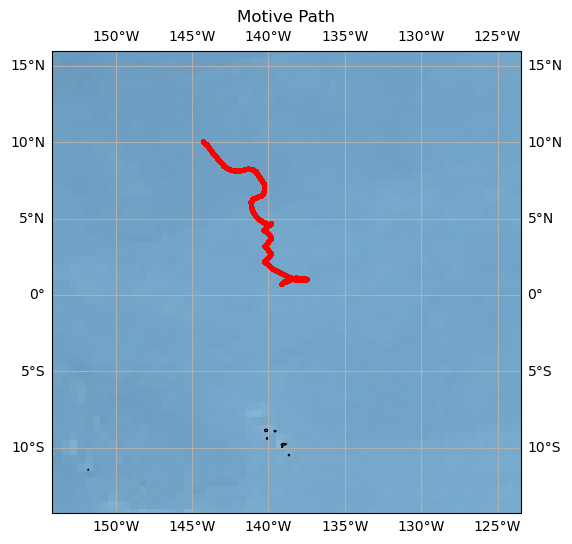

In [68]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.stock_img()
ax.plot(lon_motive, lat_motive, marker='o', markersize=2, color='red', transform=ccrs.PlateCarree())

# Compute bounds
lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

# Add a little padding (optional but recommended)
pad = 15  # degrees
ax.set_extent([lon_min - pad, lon_max + pad,
               lat_min - pad, lat_max + pad],
              crs=ccrs.PlateCarree())

plt.title("Motive Path")
plt.savefig('Seaglider_path')

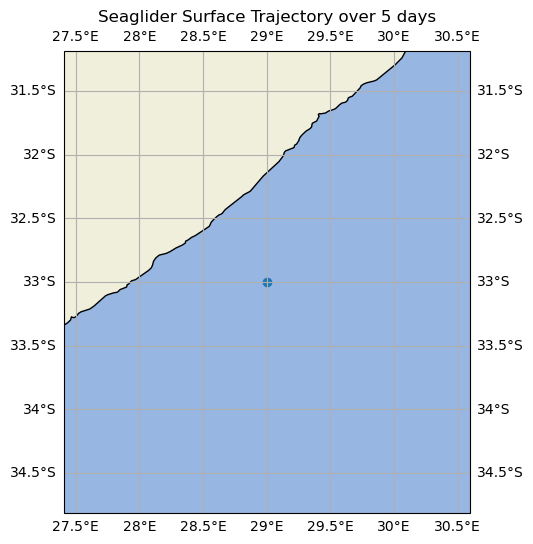

In [34]:
#mostly ignore this me just playing around with geospatial stuff

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(6,6))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.plot(lon, lat, marker="o", transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Seaglider Surface Trajectory over 5 days")

gl = ax.gridlines(draw_labels=True)

plt.show()